# Tornado Time Evolution

Reframing the radar-placement question around how tornado activity has
shifted over time and space, rather than casualty/lead-time prediction.

Core features: `BEGIN_LAT`, `BEGIN_LON`, `year`.

In [1]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import QuantileRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import mean_pinball_loss, make_scorer

# US longitudes are negative use to display them as positive degrees West on plot
lon_west_formatter = FuncFormatter(lambda x, _: f"{abs(x):.0f}°W")

## Load Cleaned Tornado Event Data

In [2]:
PROCESSED = "../data/processed/tornadoes_all.csv"

df_model = pd.read_csv(PROCESSED, index_col=0)
df_model = df_model.rename(columns={"YEAR": "year", "MONTH": "month", "TOR_F_SCALE": "ef_scale"})

print(f"Tornado events loaded : {len(df_model):,}")
print(f"Year range            : {df_model['year'].min()}-{df_model['year'].max()}")
print(f"Columns               : {list(df_model.columns)}")
df_model.head()

Tornado events loaded : 48,234
Year range            : 1990-2025
Columns               : ['year', 'month', 'BEGIN_LAT', 'BEGIN_LON', 'ef_scale']


,year,month,BEGIN_LAT,BEGIN_LON,ef_scale
0,1990,6,44.37,-92.63,1
1,1990,5,42.08,-71.40,0
2,1990,6,41.10,-98.47,0
3,1990,6,41.52,-97.73,0
4,1990,6,40.25,-100.75,4


## Spatial Shift: Early vs Recent Period

Compare tornado density maps for the first decade (1990-1999) against the
most recent decade, to visualize the tornado alley.


Early period  1990-1999 : 11,069 events
Recent period 2016-2025 : 15,160 events


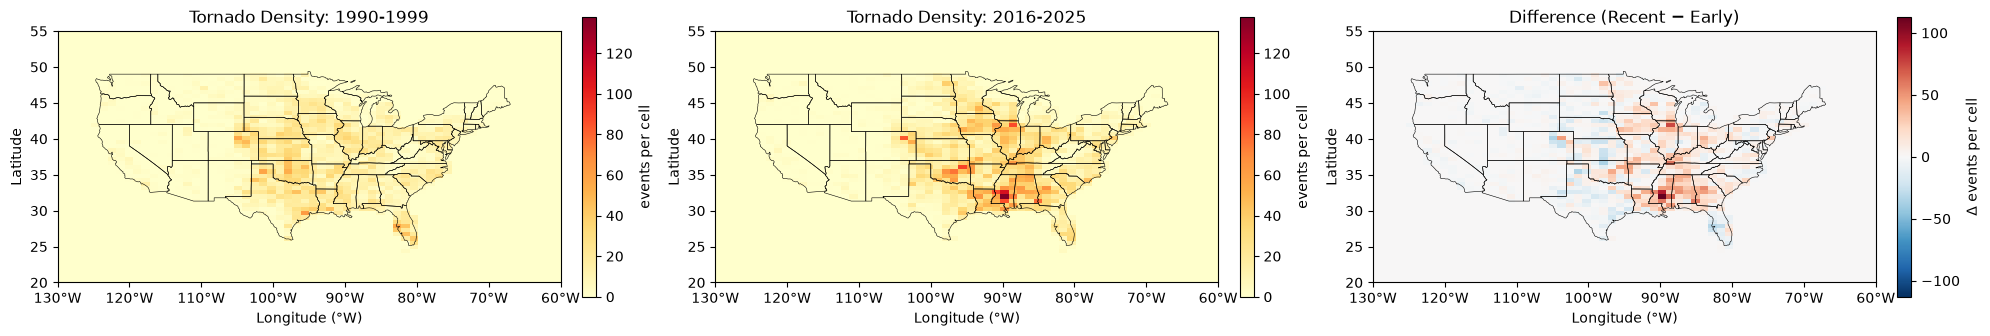

In [3]:
EARLY_START, EARLY_END = 1990, 1999
RECENT_END = df_model["year"].max()
RECENT_START = RECENT_END - 9

df_early  = df_model[(df_model["year"] >= EARLY_START) & (df_model["year"] <= EARLY_END)]
df_recent = df_model[(df_model["year"] >= RECENT_START) & (df_model["year"] <= RECENT_END)]

print(f"Early period  {EARLY_START}-{EARLY_END} : {len(df_early):,} events")
print(f"Recent period {RECENT_START}-{RECENT_END} : {len(df_recent):,} events")

# State outlines for spatial reference, fetched directly via geopandas
states = gpd.read_file(
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
)
states = states.cx[-130:-60, 20:55]  # drop AK/HI/PR etc., keep CONUS

lon_bins = np.linspace(-130, -60, 61)
lat_bins = np.linspace(20, 55, 61)

hist_early,  _, _ = np.histogram2d(df_early["BEGIN_LON"],  df_early["BEGIN_LAT"],  bins=[lon_bins, lat_bins])
hist_recent, _, _ = np.histogram2d(df_recent["BEGIN_LON"], df_recent["BEGIN_LAT"], bins=[lon_bins, lat_bins])

vmax = max(hist_early.max(), hist_recent.max())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, hist, title in zip(
    axes[:2], [hist_early, hist_recent],
    [f"{EARLY_START}-{EARLY_END}", f"{RECENT_START}-{RECENT_END}"],
):
    pcm = ax.pcolormesh(lon_bins, lat_bins, hist.T, cmap="YlOrRd", vmin=0, vmax=vmax)
    states.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Tornado Density: {title}")
    ax.set_xlabel("Longitude (°W)")
    ax.xaxis.set_major_formatter(lon_west_formatter)
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    fig.colorbar(pcm, ax=ax, label="events per cell", fraction=0.026, pad=0.04)

diff = hist_recent - hist_early
diff_max = np.abs(diff).max()
pcm_diff = axes[2].pcolormesh(lon_bins, lat_bins, diff.T, cmap="RdBu_r", vmin=-diff_max, vmax=diff_max)
states.boundary.plot(ax=axes[2], color="black", linewidth=0.4)
axes[2].set_title("Difference (Recent − Early)")
axes[2].set_xlabel("Longitude (°W)")
axes[2].xaxis.set_major_formatter(lon_west_formatter)
axes[2].set_ylabel("Latitude")
axes[2].set_aspect("equal")
fig.colorbar(pcm_diff, ax=axes[2], label="Δ events per cell", fraction=0.026, pad=0.04)

plt.tight_layout()
plt.show()

## Eastward Drift Forecast: Quantile Regression

A per-grid-cell spatiotemporal density model (Poisson regression with a
year-drift term) was tested against a spatial-only baseline, validated via
both a single holdout and rolling-origin cross-validation — it showed no
reproducible predictive improvement. 36 years of data isn't enough to
resolve the eastward drift at grid-cell resolution; the single robust trend
in longitude remains the best-supported finding in this data.

To turn that trend into a usable forecast with an uncertainty band, fit
`sklearn.linear_model.QuantileRegressor` (quantile 0.16, 0.50, 0.84, i.e. 2$\sigma$)
directly on individual events (`year -> BEGIN_LON`).

Events are split 80/20 into training and test sets, stratified by year so
each year's share of events is preserved in both sets (early years have far
fewer events than recent ones). The model is validated with year-stratified
5-fold cross-validation on the training set (mean pinball loss per
quantile), refit on the full training set, and then checked once against
the held-out test set for an unbiased performance estimate.

The overall model training and testing in the next cell takes several minutes 
to run (~6 minutes).


In [4]:
FORECAST_YEAR = 2030
REF_YEAR = df_model["year"].max()  # 2025; center year for numerical stability

X_year = (df_model["year"].values - REF_YEAR).reshape(-1, 1)
y_lon  = df_model["BEGIN_LON"].values
year_labels = df_model["year"].values

# Hold out 20% of events for a final, unbiased check; validate on the
# remaining 80% via 5-fold CV before refitting on the full training set.
# Stratify by year so both the split and every CV fold preserve each
# year's share of events (early years have far fewer events than recent ones).
X_train, X_test, y_train, y_test, year_train, year_test = train_test_split(
    X_year, y_lon, year_labels, test_size=0.2, random_state=42, stratify=year_labels
)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(skfold.split(X_train, year_train))

quantiles = [0.16, 0.50, 0.84]
qr_models = {}

print("Starting quantile regression training on tornado event data!")
print("This could take a while (5+ minutes)...")


print("5-fold CV on training set (80%), then held-out test set (20%):")
for q in quantiles:
    qr = QuantileRegressor(quantile=q, alpha=0.0, solver="highs")

    cv_losses = -cross_val_score(
        qr, X_train, y_train, cv=cv_splits,
        scoring=make_scorer(mean_pinball_loss, alpha=q, greater_is_better=False),
    )
    qr.fit(X_train, y_train)
    test_loss = mean_pinball_loss(y_test, qr.predict(X_test), alpha=q)
    qr_models[q] = qr

    print(f"  q={q:.2f} : CV pinball loss = {cv_losses.mean():.4f} ± {cv_losses.std():.4f}  "
          f"| test pinball loss = {test_loss:.4f}")

km_per_deg_lon = 111.0 * np.cos(np.deg2rad(df_model["BEGIN_LAT"].mean()))

print("\nQuantile regression slopes (fit on 80% training set):")
for q in quantiles:
    slope = qr_models[q].coef_[0]
    print(f"  q={q:.2f} : {slope:+.4f}°/yr  ({slope*10:+.2f}°/decade, {slope*10*km_per_deg_lon:+.1f} km/decade)")

qr_median_slope = qr_models[0.50].coef_[0]
print(f"\nMedian regression slope (training set)  : {qr_median_slope:+.4f}°/yr "
      f"-> {qr_median_slope*10*km_per_deg_lon:+.1f} km/decade")

# Forecast: last observed year vs FORECAST_YEAR
X_last     = np.array([[df_model["year"].max() - REF_YEAR]])
X_forecast = np.array([[FORECAST_YEAR - REF_YEAR]])

last_pred     = {q: qr_models[q].predict(X_last)[0]     for q in quantiles}
forecast_pred = {q: qr_models[q].predict(X_forecast)[0] for q in quantiles}

print(f"\nFitted longitude for {df_model['year'].max()} (last observed year):")
for q in quantiles:
    print(f"  q={q:.2f} : {last_pred[q]:+.2f}°")

print(f"\nForecast longitude for {FORECAST_YEAR}:")
for q in quantiles:
    print(f"  q={q:.2f} : {forecast_pred[q]:+.2f}°")

shift_deg = forecast_pred[0.50] - last_pred[0.50]
print(f"\nProjected median eastward shift {df_model['year'].max()}->{FORECAST_YEAR}: "
      f"{shift_deg:+.2f}°  ({shift_deg*km_per_deg_lon:+.1f} km)")

Starting quantile regression training on tornado event data!
This could take a while (5+ minutes)...
5-fold CV on training set (80%), then held-out test set (20%):
  q=0.16 : CV pinball loss = 1.9524 ± 0.0276  | test pinball loss = 1.9274
  q=0.50 : CV pinball loss = 3.2722 ± 0.0196  | test pinball loss = 3.2638
  q=0.84 : CV pinball loss = 2.0112 ± 0.0167  | test pinball loss = 2.0150

Quantile regression slopes (fit on 80% training set):
  q=0.16 : +0.1172°/yr  (+1.17°/decade, +103.7 km/decade)
  q=0.50 : +0.1394°/yr  (+1.39°/decade, +123.3 km/decade)
  q=0.84 : -0.0153°/yr  (-0.15°/decade, -13.5 km/decade)

Median regression slope (training set)  : +0.1394°/yr -> +123.3 km/decade

Fitted longitude for 2025 (last observed year):
  q=0.16 : -97.90°
  q=0.50 : -90.19°
  q=0.84 : -84.05°

Forecast longitude for 2030:
  q=0.16 : -97.31°
  q=0.50 : -89.49°
  q=0.84 : -84.13°

Projected median eastward shift 2025->2030: +0.70°  (+61.6 km)


## Plotting model result and 2030 prediction for longitudinal shift. 


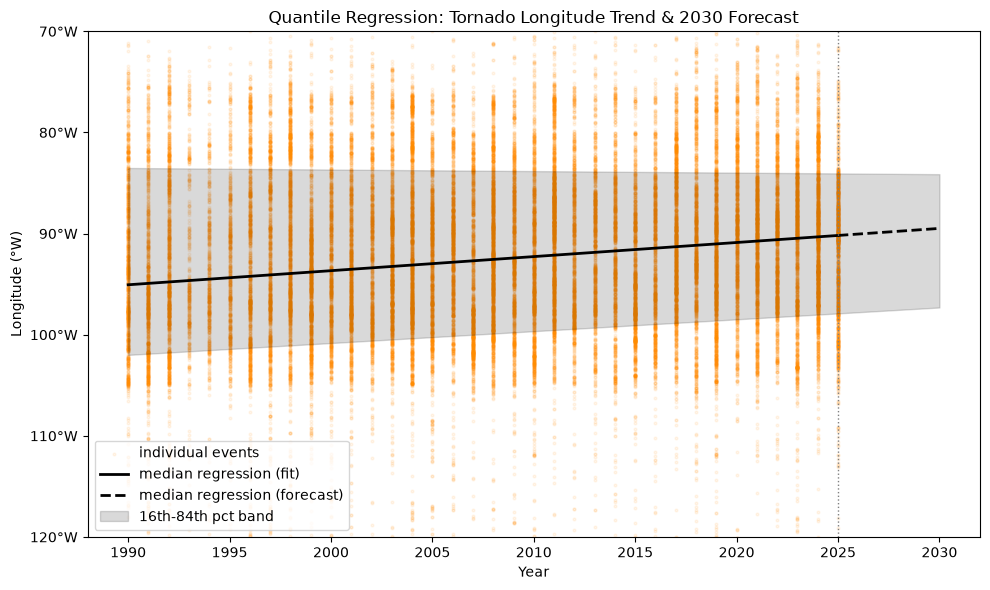

In [9]:
years_plot = np.arange(df_model["year"].min(), FORECAST_YEAR + 1)
X_plot = (years_plot - REF_YEAR).reshape(-1, 1)

pred_lo  = qr_models[0.16].predict(X_plot)
pred_med = qr_models[0.50].predict(X_plot)
pred_hi  = qr_models[0.84].predict(X_plot)

obs_mask = years_plot <= df_model["year"].max()
fc_mask  = years_plot >= df_model["year"].max()  # overlap at boundary so the lines connect

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_model["year"], df_model["BEGIN_LON"], s=4, alpha=0.08, color="darkorange", label="individual events")

ax.plot(years_plot[obs_mask], pred_med[obs_mask], color="black", lw=2, label="median regression (fit)")
ax.plot(years_plot[fc_mask], pred_med[fc_mask], color="black", lw=2, ls="--", label="median regression (forecast)")
ax.fill_between(years_plot, pred_lo, pred_hi, color="black", alpha=0.15, label="16th-84th pct band")

ax.axvline(df_model["year"].max(), color="gray", ls=":", lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("Longitude (°W)")
ax.set_ylim([-120, -70])
ax.yaxis.set_major_formatter(lon_west_formatter)
ax.set_title(f"Quantile Regression: Tornado Longitude Trend & {FORECAST_YEAR} Forecast")
ax.legend(loc="lower left", facecolor="white")

plt.tight_layout()
plt.savefig("../plots/TornadoLongitudeQuantileRegression.pdf",bbox_inches='tight')

## Summary: Radar Coverage vs. Predicted 2030 Tornado Longitude

Existing WSR-88D radar sites plotted with a 100 km detection-range circle
each, overlaid with the model's predicted 2030 tornado longitude band
(16th-84th pct, from the quantile regression above) to highlight where
coverage gaps line up with where tornado activity is expected to shift.

Radars can detect percipitation up to 230+ km away but can only detect 
tornado structure and location with accuracy up to about 100 km away.


Operational CONUS radars plotted: 138


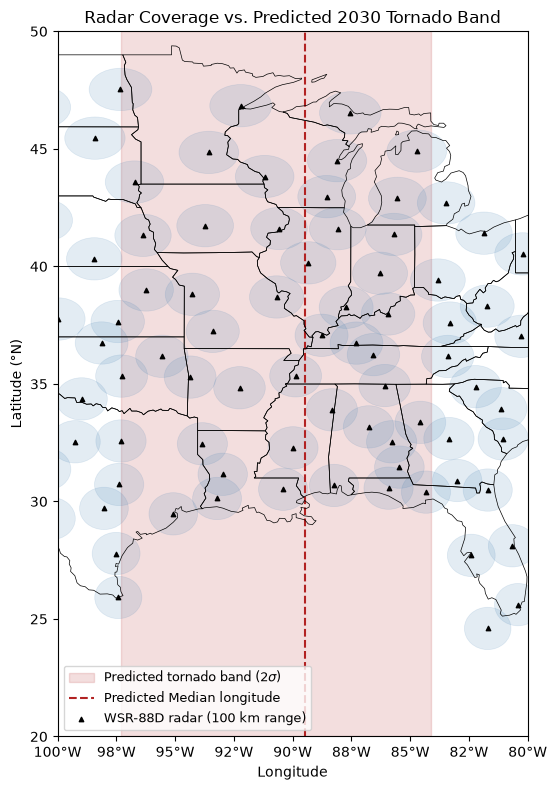

In [10]:
RADAR_RANGE_KM = 100  # detection-range radius per radar

with open("../data/raw/nexrad_sites.json") as f:
    nexrad = json.load(f)

radar_lon, radar_lat = [], []
for feat in nexrad["features"]:
    props = feat["properties"]
    if props.get("rda") and props["rda"]["properties"].get("status") == "Operate":
        lon, lat = feat["geometry"]["coordinates"]
        radar_lon.append(lon)
        radar_lat.append(lat)

radar_lon, radar_lat = np.array(radar_lon), np.array(radar_lat)
conus_mask = (radar_lon >= -130) & (radar_lon <= -60) & (radar_lat >= 20) & (radar_lat <= 55)
radar_lon, radar_lat = radar_lon[conus_mask], radar_lat[conus_mask]

fig, ax = plt.subplots(figsize=(12, 8))

# Predicted 2030 tornado longitude band (16th-84th pct) from the quantile
# regression forecast above
lon_lo, lon_hi = forecast_pred[0.16], forecast_pred[0.84]
ax.axvspan(lon_lo, lon_hi, color="firebrick", alpha=0.15,
           label=r"Predicted tornado band (2$\sigma$)")
ax.axvline(forecast_pred[0.50], color="firebrick", linestyle="--", linewidth=1.5,
           label=f"Predicted Median longitude")

# Detection-range circles: true km circles render as ellipses in lon/lat
# degree-space since a degree of longitude shrinks with latitude
for lon, lat in zip(radar_lon, radar_lat):
    dlon = RADAR_RANGE_KM / (111.0 * np.cos(np.deg2rad(lat)))
    dlat = RADAR_RANGE_KM / 111.0
    ax.add_patch(Ellipse(
        (lon, lat), width=2 * dlon, height=2 * dlat,
        facecolor="steelblue", alpha=0.15, edgecolor="steelblue", linewidth=0.5,
    ))

ax.scatter(radar_lon, radar_lat, s=10, color="k", marker="^",
           label=f"WSR-88D radar ({RADAR_RANGE_KM} km range)", zorder=5)

states.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.set_xlim(-100, -80)
ax.set_ylim(20, 50)
ax.set_aspect("equal")
ax.xaxis.set_major_formatter(lon_west_formatter)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude (°N)")
ax.set_title(f"Radar Coverage vs. Predicted 2030 Tornado Band")
ax.legend(loc="lower left", fontsize=9, facecolor="white")
plt.tight_layout()
plt.savefig("../plots/Predicted2030TornadoHotSpotVsRadarCoverage.pdf", bbox_inches='tight')